# Smart Crop Health Monitoring: Plant Disease Detection

**Clean Kaggle Notebook Version**

This notebook is the structured version of the original end-to-end Kaggle code.  
The earlier code was implemented in one large cell; this version separates the work into clear sections for readability, marking evidence, debugging, and presentation.

## Project aim

Build and evaluate a deep-learning computer vision model that classifies plant leaf images into **23 disease/healthy classes** across five crops:

- Apple
- Corn/Maize
- Pepper bell
- Potato
- Tomato

## Final workflow

1. Setup and configuration  
2. Dataset audit and EDA  
3. Duplicate candidate detection  
4. Train/validation/test manifest creation  
5. PyTorch Dataset and transforms  
6. EfficientNet-B2 model training  
7. Evaluation with metrics and visualisations  
8. Grad-CAM explainability  
9. Artifact export for VS Code and Hugging Face deployment

## Running this notebook in Kaggle

Before running:

1. Attach the **Plant Disease Detection** dataset to the Kaggle notebook.
2. Confirm that the dataset path is:

```text
/kaggle/input/plant-disease-detection/Dataset
```

3. Run cells from top to bottom.
4. Exported files will appear in:

```text
/kaggle/working/exports
```

Key exported files include `best_model.pt`, `labels.json`, `config.json`, `metrics.json`, `classification_report.csv`, `confusion_matrix.png`, `per_class_accuracy.png`, and `gradcam_samples.png`.

> ## 0. Setup

**Purpose:** Imports core libraries, controls randomness for reproducibility, selects GPU/CPU, and enables mixed precision when CUDA is available.

In [13]:
# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError
import imagehash

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print("Using device:", DEVICE)
print("AMP enabled:", USE_AMP)


Using device: cuda
AMP enabled: True


## 1. Configuration

**Purpose:** Defines Kaggle input/output paths, training hyperparameters, class labels, and writes deployment-ready `config.json` and `labels.json`.

In [14]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
INPUT_BASE = Path("/kaggle/input/plant-disease-detection/Dataset")
WORKING_BASE = Path("/kaggle/working/plant_disease_kaggle_first")
EXPORT_DIR = Path("/kaggle/working/exports")
WORKING_BASE.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 1e-4
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
PATIENCE = 5
USE_EFFICIENTNET = True
LABEL_SMOOTHING = 0.1
TOP_K = 5

# IMPORTANT:
# Set False when Kaggle internet is disabled and torchvision weights cannot be downloaded.
USE_PRETRAINED_WEIGHTS = False

CATEGORIES = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy',
]
NUM_CLASSES = len(CATEGORIES)
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

config = {
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "patience": PATIENCE,
    "use_efficientnet": USE_EFFICIENTNET,
    "label_smoothing": LABEL_SMOOTHING,
    "seed": SEED,
    "top_k": TOP_K,
    "use_pretrained_weights": USE_PRETRAINED_WEIGHTS,
}
with open(EXPORT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)
with open(EXPORT_DIR / "labels.json", "w", encoding="utf-8") as f:
    json.dump(CATEGORIES, f, indent=2)

print("Classes:", NUM_CLASSES)


Classes: 23


## 2. Dataset Audit

**Purpose:** Checks all image folders, validates readable files, records image dimensions, and exports `audit.csv` and `audit_summary.json`.

In [15]:
# ------------------------------------------------------------
# Dataset Audit
# ------------------------------------------------------------
rows = []
for category in CATEGORIES:
    class_dir = INPUT_BASE / category
    if not class_dir.exists():
        rows.append({
            "class_name": category,
            "path": None,
            "filename": None,
            "size_bytes": None,
            "width": None,
            "height": None,
            "status": "missing_folder",
        })
        continue

    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() not in VALID_EXTS:
            continue

        status = "ok"
        width = height = None
        try:
            with Image.open(img_path) as im:
                im = im.convert("RGB")
                width, height = im.size
        except (UnidentifiedImageError, OSError):
            status = "corrupt"

        rows.append({
            "class_name": category,
            "path": str(img_path),
            "filename": img_path.name,
            "size_bytes": img_path.stat().st_size if img_path.exists() else None,
            "width": width,
            "height": height,
            "status": status,
        })

audit_df = pd.DataFrame(rows)
audit_df.to_csv(EXPORT_DIR / "audit.csv", index=False)

audit_summary = {
    "total_rows": int(len(audit_df)),
    "ok_images": int((audit_df["status"] == "ok").sum()),
    "corrupt_images": int((audit_df["status"] == "corrupt").sum()),
    "missing_folders": int((audit_df["status"] == "missing_folder").sum()),
    "num_classes": int(NUM_CLASSES),
}
with open(EXPORT_DIR / "audit_summary.json", "w", encoding="utf-8") as f:
    json.dump(audit_summary, f, indent=2)

print("Audit summary:", audit_summary)
print(audit_df["status"].value_counts(dropna=False))


Audit summary: {'total_rows': 35725, 'ok_images': 35725, 'corrupt_images': 0, 'missing_folders': 0, 'num_classes': 23}
status
ok    35725
Name: count, dtype: int64


## 3. EDA

**Purpose:** Explores class balance and image-size distributions so dataset quality and imbalance can be discussed in the report.

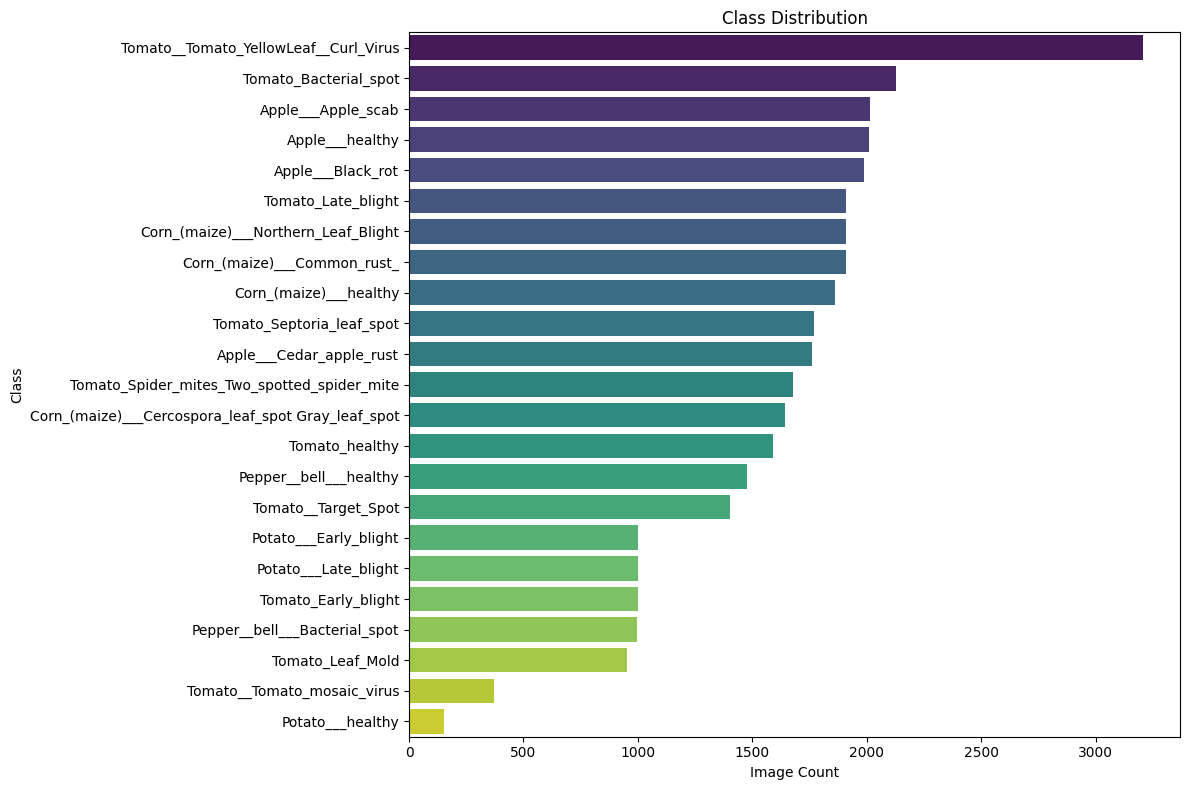

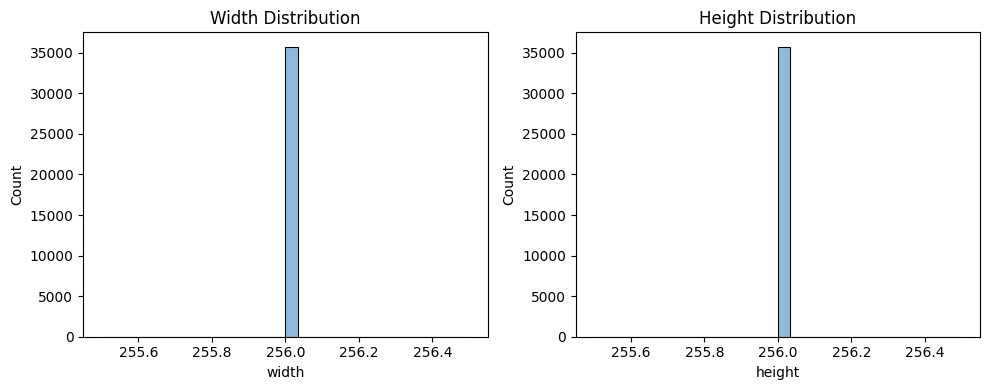

In [16]:
# ------------------------------------------------------------
# EDA
# ------------------------------------------------------------
usable_audit = audit_df[audit_df["status"] == "ok"].copy()

class_counts = usable_audit.groupby("class_name").size().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
plt.title("Class Distribution")
plt.xlabel("Image Count")
plt.ylabel("Class")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "class_distribution.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(audit_df["width"].dropna(), bins=30, kde=True)
plt.title("Width Distribution")
plt.subplot(1, 2, 2)
sns.histplot(audit_df["height"].dropna(), bins=30, kde=True)
plt.title("Height Distribution")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "image_size_distribution.png", dpi=160)
plt.show()

class_balance_df = class_counts.reset_index()
class_balance_df.columns = ["class_name", "count"]
class_balance_df["ratio_to_max"] = class_balance_df["count"] / class_balance_df["count"].max()
class_balance_df.to_csv(EXPORT_DIR / "class_balance_report.csv", index=False)


## 4. Duplicate Candidate Detection

**Purpose:** Uses perceptual hashing to flag visually similar or duplicate images that may create leakage risks.

In [17]:
# ------------------------------------------------------------
# Duplicate Candidate Detection
# ------------------------------------------------------------
def phash_safe(path):
    try:
        with Image.open(path) as im:
            im = im.convert("RGB")
            return str(imagehash.phash(im))
    except Exception:
        return None

sample_for_hash = usable_audit.copy()
sample_for_hash["phash"] = sample_for_hash["path"].apply(phash_safe)
dupes = sample_for_hash[sample_for_hash["phash"].duplicated(keep=False)].sort_values("phash")
dupes.to_csv(EXPORT_DIR / "duplicate_candidates.csv", index=False)
print("Potential duplicate rows:", len(dupes))


Potential duplicate rows: 78


## 5. Create Train / Val / Test Manifests

**Purpose:** Creates stratified train, validation, and test manifests so the final evaluation uses held-out images.

In [18]:
# ------------------------------------------------------------
# Create Train / Val / Test Manifests
# ------------------------------------------------------------
usable_df = audit_df[audit_df["status"] == "ok"].copy()

def create_split_manifests(df, train_ratio=0.70, val_ratio=0.15, seed=42):
    rng = random.Random(seed)
    train_rows, val_rows, test_rows = [], [], []

    for class_name, sub in df.groupby("class_name"):
        rows = sub.to_dict("records")
        rng.shuffle(rows)
        n = len(rows)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_rows.extend(rows[:n_train])
        val_rows.extend(rows[n_train:n_train + n_val])
        test_rows.extend(rows[n_train + n_val:])

    return (
        pd.DataFrame(train_rows).assign(split="train"),
        pd.DataFrame(val_rows).assign(split="val"),
        pd.DataFrame(test_rows).assign(split="test"),
    )

train_df, val_df, test_df = create_split_manifests(usable_df, TRAIN_RATIO, VAL_RATIO, SEED)
train_df.to_csv(EXPORT_DIR / "train_manifest.csv", index=False)
val_df.to_csv(EXPORT_DIR / "val_manifest.csv", index=False)
test_df.to_csv(EXPORT_DIR / "test_manifest.csv", index=False)

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "count": [len(train_df), len(val_df), len(test_df)],
})
split_summary.to_csv(EXPORT_DIR / "split_summary.csv", index=False)
print(split_summary)


   split  count
0  train  24997
1    val   5350
2   test   5378


## 6. Dataset Class

**Purpose:** Implements a reusable PyTorch Dataset class for loading image paths and labels from manifest files.

In [19]:
# ------------------------------------------------------------
# Dataset Class
# ------------------------------------------------------------
class ManifestImageDataset(Dataset):
    def __init__(self, manifest_df, categories, transform=None):
        self.df = manifest_df.reset_index(drop=True).copy()
        self.categories = categories
        self.class_to_idx = {c: i for i, c in enumerate(categories)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}
        self.transform = transform
        self.labels = [self.class_to_idx[c] for c in self.df["class_name"].tolist()]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        label = self.class_to_idx[row["class_name"]]

        try:
            img = Image.open(path).convert("RGB")
        except (UnidentifiedImageError, OSError):
            return self.__getitem__((idx + 1) % len(self))

        if self.transform:
            img = self.transform(img)
        return img, label

    def class_weights(self):
        counts = np.bincount(self.labels, minlength=len(self.idx_to_class))
        weights = 1.0 / (counts + 1e-6)
        return torch.tensor(weights, dtype=torch.float32)


## 7. Transforms

**Purpose:** Defines training augmentation and validation/test preprocessing using ImageNet-style normalisation.

In [20]:
# ------------------------------------------------------------
# Transforms
# ------------------------------------------------------------
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = ManifestImageDataset(train_df, CATEGORIES, train_tf)
val_ds = ManifestImageDataset(val_df, CATEGORIES, eval_tf)
test_ds = ManifestImageDataset(test_df, CATEGORIES, eval_tf)

sample_weights = train_ds.class_weights()[train_ds.labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, **loader_kwargs)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))


Dataset sizes: 24997 5350 5378


## 8. Offline-Safe Model Factory

**Purpose:** Builds EfficientNet-B2 or ResNet-50 without downloading pretrained weights, making the notebook safe for offline Kaggle execution.

In [21]:
# ------------------------------------------------------------
# Offline-Safe Model Factory
# ------------------------------------------------------------
def build_model(num_classes, use_efficientnet=True, use_pretrained=False):
    """
    Offline-safe model builder.
    If use_pretrained=False, no download is attempted.
    """

    if use_efficientnet:
        try:
            from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
            eff_weights = EfficientNet_B2_Weights.DEFAULT if use_pretrained else None
            model = efficientnet_b2(weights=eff_weights)
            in_features = model.classifier[1].in_features
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, num_classes),
            )
            print(
                "Using EfficientNet-B2 with pretrained weights"
                if use_pretrained else
                "Using EfficientNet-B2 without pretrained weights"
            )
            return model
        except Exception as e:
            print("Falling back to ResNet-50:", e)

    from torchvision.models import resnet50, ResNet50_Weights
    res_weights = ResNet50_Weights.DEFAULT if use_pretrained else None
    model = resnet50(weights=res_weights)
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes),
    )
    print(
        "Using ResNet-50 with pretrained weights"
        if use_pretrained else
        "Using ResNet-50 without pretrained weights"
    )
    return model

model = build_model(
    NUM_CLASSES,
    use_efficientnet=USE_EFFICIENTNET,
    use_pretrained=USE_PRETRAINED_WEIGHTS,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Using EfficientNet-B2 without pretrained weights


## 9. Early Stopping

**Purpose:** Provides a small early-stopping helper to protect against overfitting and unnecessary training.

In [22]:
# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------
class EarlyStopping:
    def __init__(self, patience, path):
        self.patience = patience
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            torch.save(model.state_dict(), self.path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


## 10. Train / Validation Epoch

**Purpose:** Defines reusable epoch functions for training and validation with AMP, gradient clipping, loss, and accuracy tracking.

In [23]:
# ------------------------------------------------------------
# Train / Validation Epoch
# ------------------------------------------------------------
def run_epoch(model, loader, criterion, optimizer=None, phase="train"):
    is_train = phase == "train"
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    return total_loss / total, correct / total, all_preds, all_labels


## 11. Training Loop

**Purpose:** Runs the full training process, saves the best model checkpoint, and exports training history.

In [24]:
# ------------------------------------------------------------
# Training Loop
# ------------------------------------------------------------
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
stopper = EarlyStopping(PATIENCE, EXPORT_DIR / "best_model.pt")

for epoch in range(EPOCHS):
    tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer, "train")
    vl_loss, vl_acc, _, _ = run_epoch(model, val_loader, criterion, phase="val")
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={tr_loss:.4f} | train_acc={tr_acc:.4f} | "
        f"val_loss={vl_loss:.4f} | val_acc={vl_acc:.4f}"
    )

    stopper(vl_loss, model)
    if stopper.early_stop:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(EXPORT_DIR / "training_history.csv", index=False)


Epoch 1/20 | train_loss=2.5206 | train_acc=0.2673 | val_loss=1.6985 | val_acc=0.5793
Epoch 2/20 | train_loss=1.7076 | train_acc=0.5740 | val_loss=1.2465 | val_acc=0.7630
Epoch 3/20 | train_loss=1.3227 | train_acc=0.7270 | val_loss=0.9836 | val_acc=0.8596
Epoch 4/20 | train_loss=1.0924 | train_acc=0.8213 | val_loss=0.8905 | val_acc=0.8970
Epoch 5/20 | train_loss=0.9881 | train_acc=0.8627 | val_loss=0.8122 | val_acc=0.9357
Epoch 6/20 | train_loss=0.9140 | train_acc=0.8873 | val_loss=0.7769 | val_acc=0.9439
Epoch 7/20 | train_loss=0.8671 | train_acc=0.9062 | val_loss=0.7582 | val_acc=0.9477
Epoch 8/20 | train_loss=0.8344 | train_acc=0.9199 | val_loss=0.7076 | val_acc=0.9664
Epoch 9/20 | train_loss=0.7945 | train_acc=0.9349 | val_loss=0.7113 | val_acc=0.9679
Epoch 10/20 | train_loss=0.7761 | train_acc=0.9407 | val_loss=0.6941 | val_acc=0.9693
Epoch 11/20 | train_loss=0.7521 | train_acc=0.9502 | val_loss=0.6974 | val_acc=0.9692
Epoch 12/20 | train_loss=0.7371 | train_acc=0.9563 | val_loss=0

## 12. Training Curves

**Purpose:** Plots loss and accuracy curves for technical evaluation and report evidence.

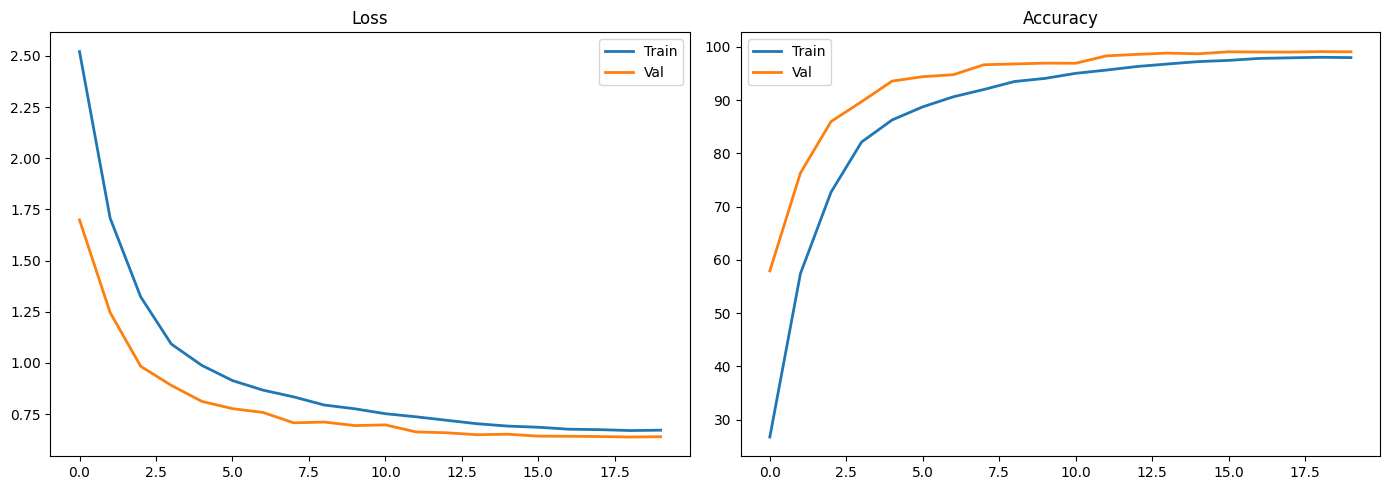

In [25]:
# ------------------------------------------------------------
# Training Curves
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="Train", linewidth=2)
axes[0].plot(history["val_loss"], label="Val", linewidth=2)
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot([x * 100 for x in history["train_acc"]], label="Train", linewidth=2)
axes[1].plot([x * 100 for x in history["val_acc"]], label="Val", linewidth=2)
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(EXPORT_DIR / "training_curves.png", dpi=160)
plt.show()


## 13. Evaluation

**Purpose:** Evaluates the best checkpoint on the test set and exports metrics, classification report, confusion matrix, and per-class accuracy.

Using EfficientNet-B2 without pretrained weights
Metrics: {'test_accuracy': 0.9905169207883971, 'macro_precision': 0.9880172763500356, 'macro_recall': 0.990606438724643, 'macro_f1': 0.9892629580187863, 'epochs_completed': 20}


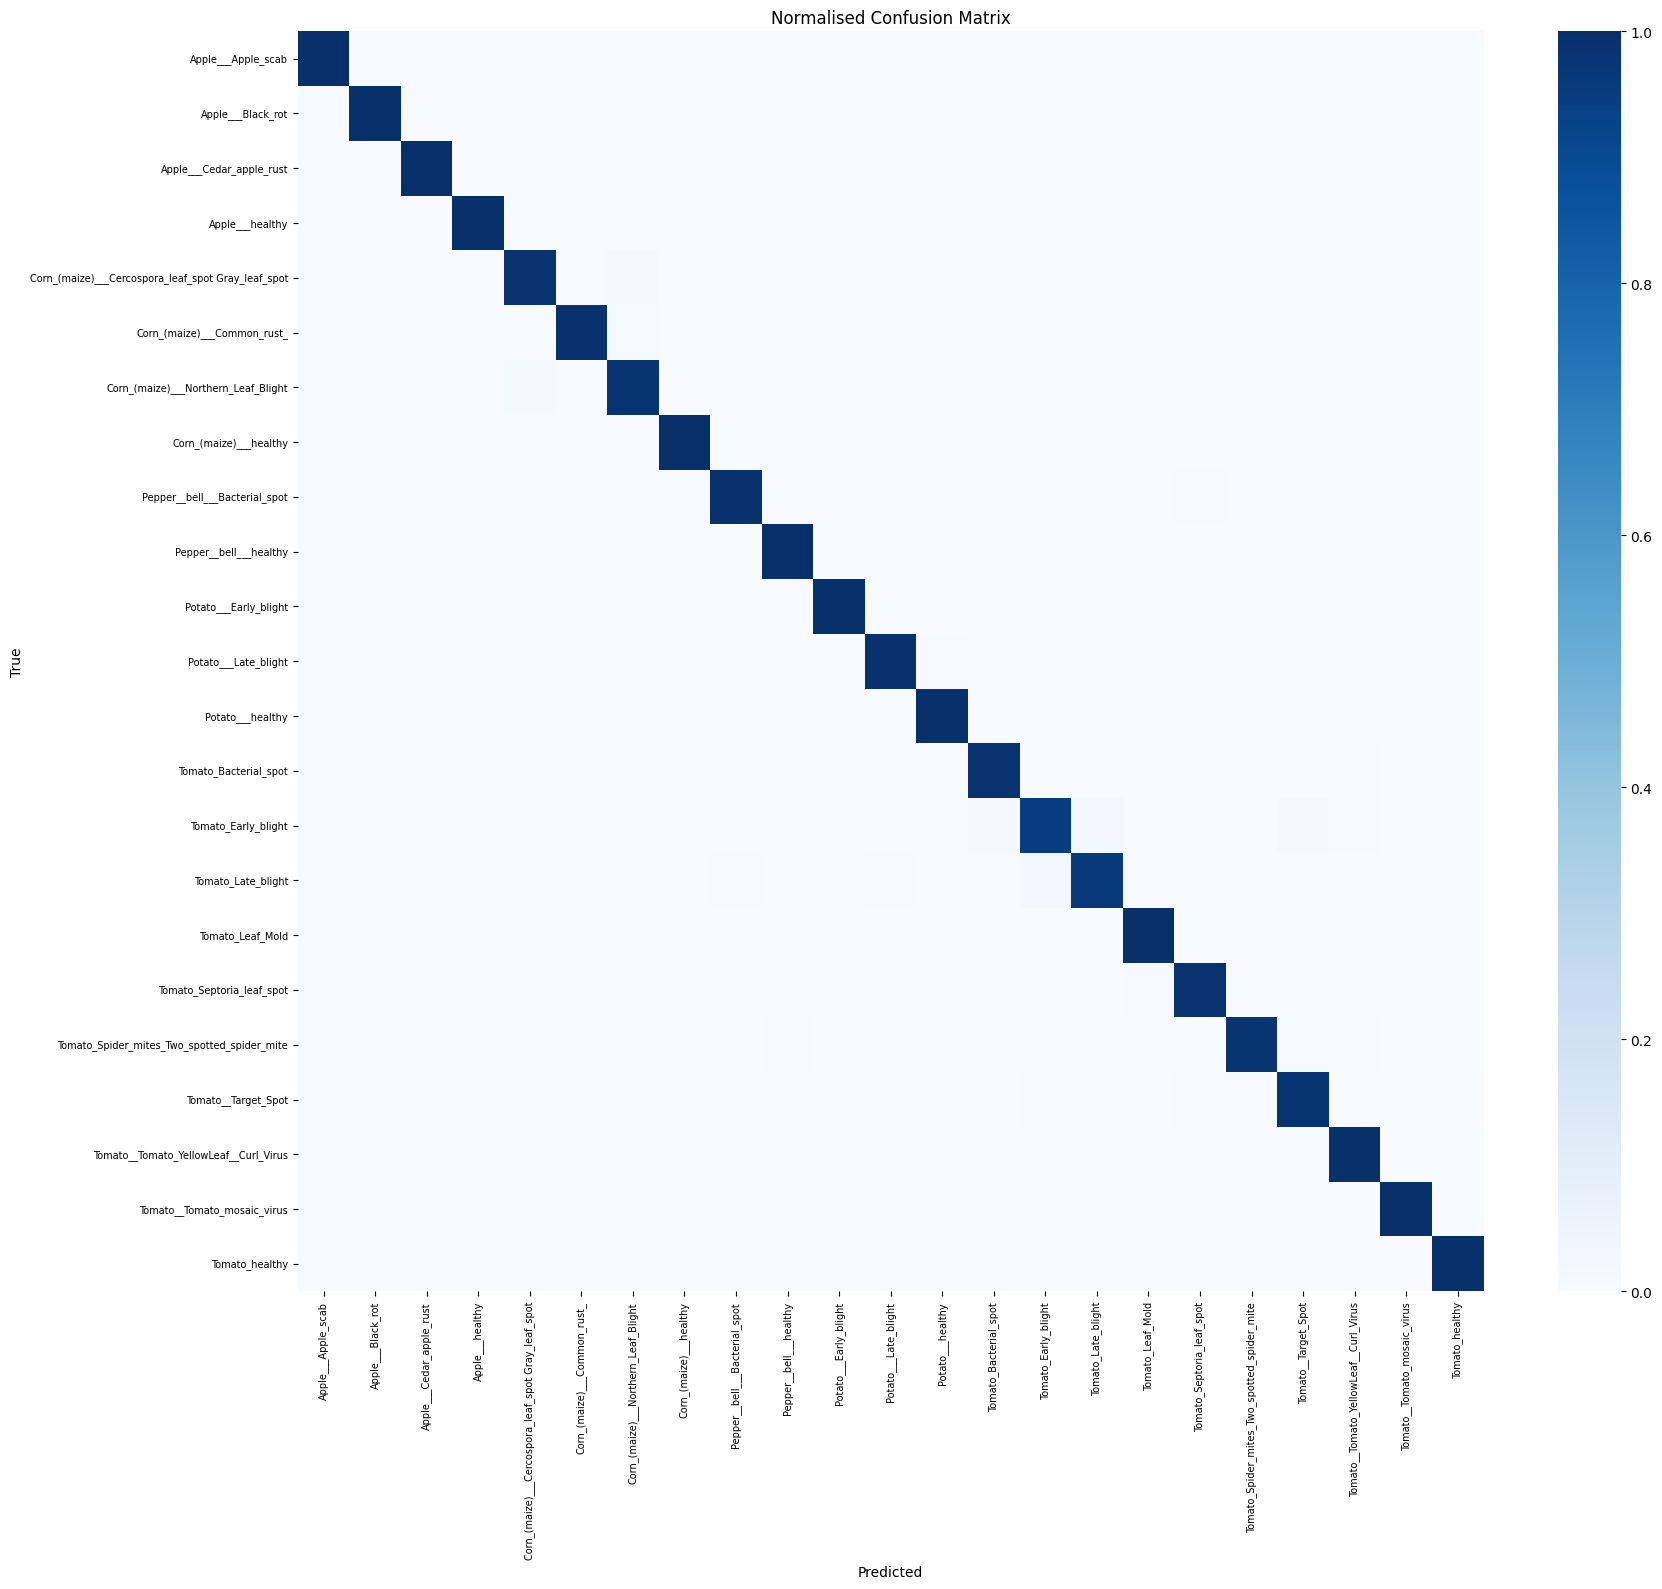

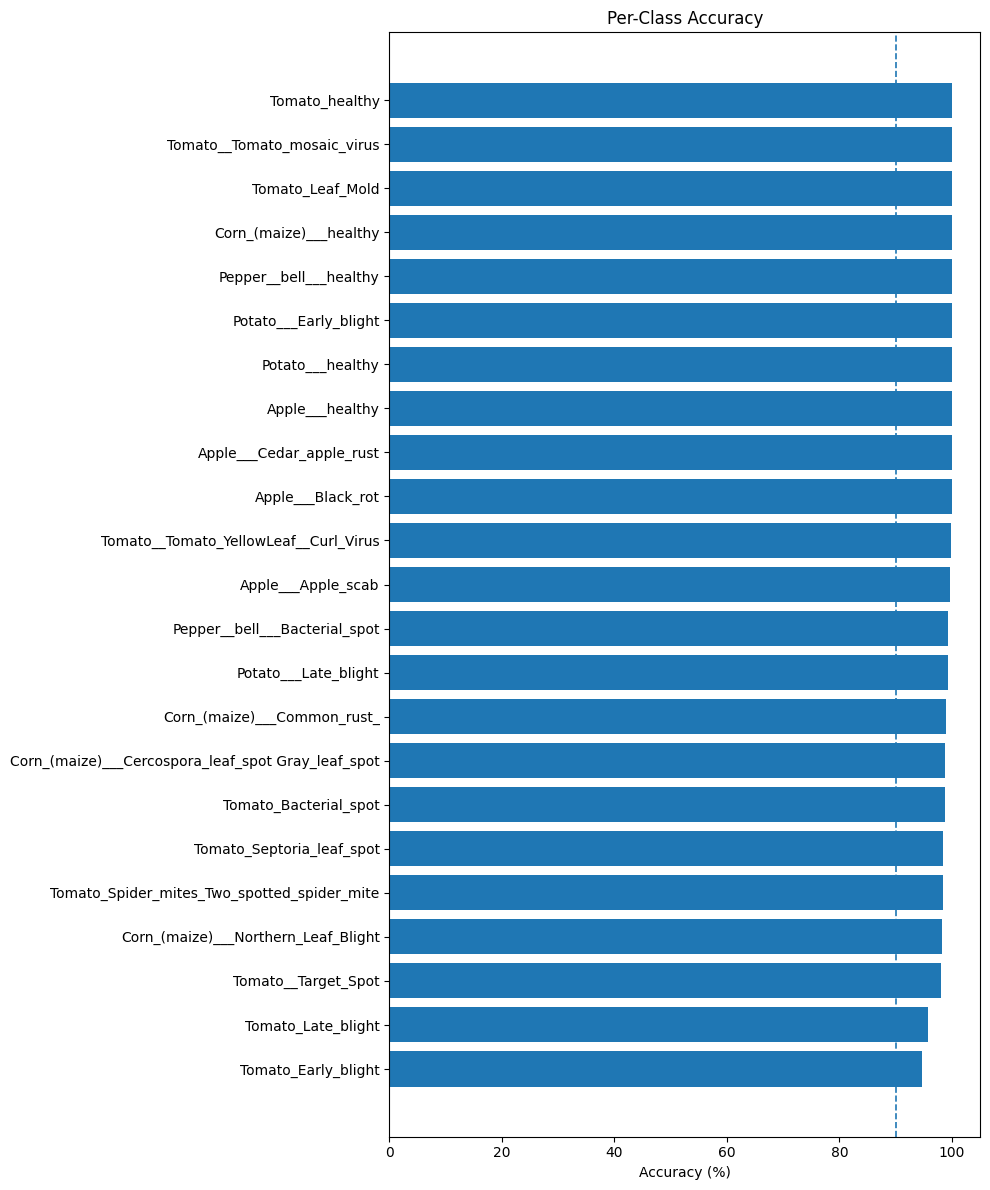

In [26]:
# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
best_model = build_model(
    NUM_CLASSES,
    use_efficientnet=USE_EFFICIENTNET,
    use_pretrained=False,   # important when loading your own checkpoint
).to(DEVICE)

best_model.load_state_dict(torch.load(EXPORT_DIR / "best_model.pt", map_location=DEVICE))
best_model.eval()

_, _, all_preds, all_labels = run_epoch(best_model, test_loader, criterion, phase="val")

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=CATEGORIES,
    digits=3,
    output_dict=True,
)
pd.DataFrame(report_dict).transpose().to_csv(EXPORT_DIR / "classification_report.csv")

test_acc = float((np.array(all_preds) == np.array(all_labels)).mean())
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0,
)

metrics_payload = {
    "test_accuracy": test_acc,
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "epochs_completed": len(history["train_loss"]),
}
with open(EXPORT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

print("Metrics:", metrics_payload)

cm = confusion_matrix(all_labels, all_preds)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(18, 16))
sns.heatmap(cm_norm, cmap="Blues", xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title("Normalised Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "confusion_matrix.png", dpi=160)
plt.show()

per_class_acc = cm_norm.diagonal() * 100
sort_idx = np.argsort(per_class_acc)

plt.figure(figsize=(10, 12))
plt.barh([CATEGORIES[i] for i in sort_idx], per_class_acc[sort_idx])
plt.axvline(90, linestyle="--", linewidth=1.2)
plt.xlabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "per_class_accuracy.png", dpi=160)
plt.show()


## 14. Grad-CAM

**Purpose:** Generates Grad-CAM visual explanations so model attention can be inspected beyond accuracy metrics.

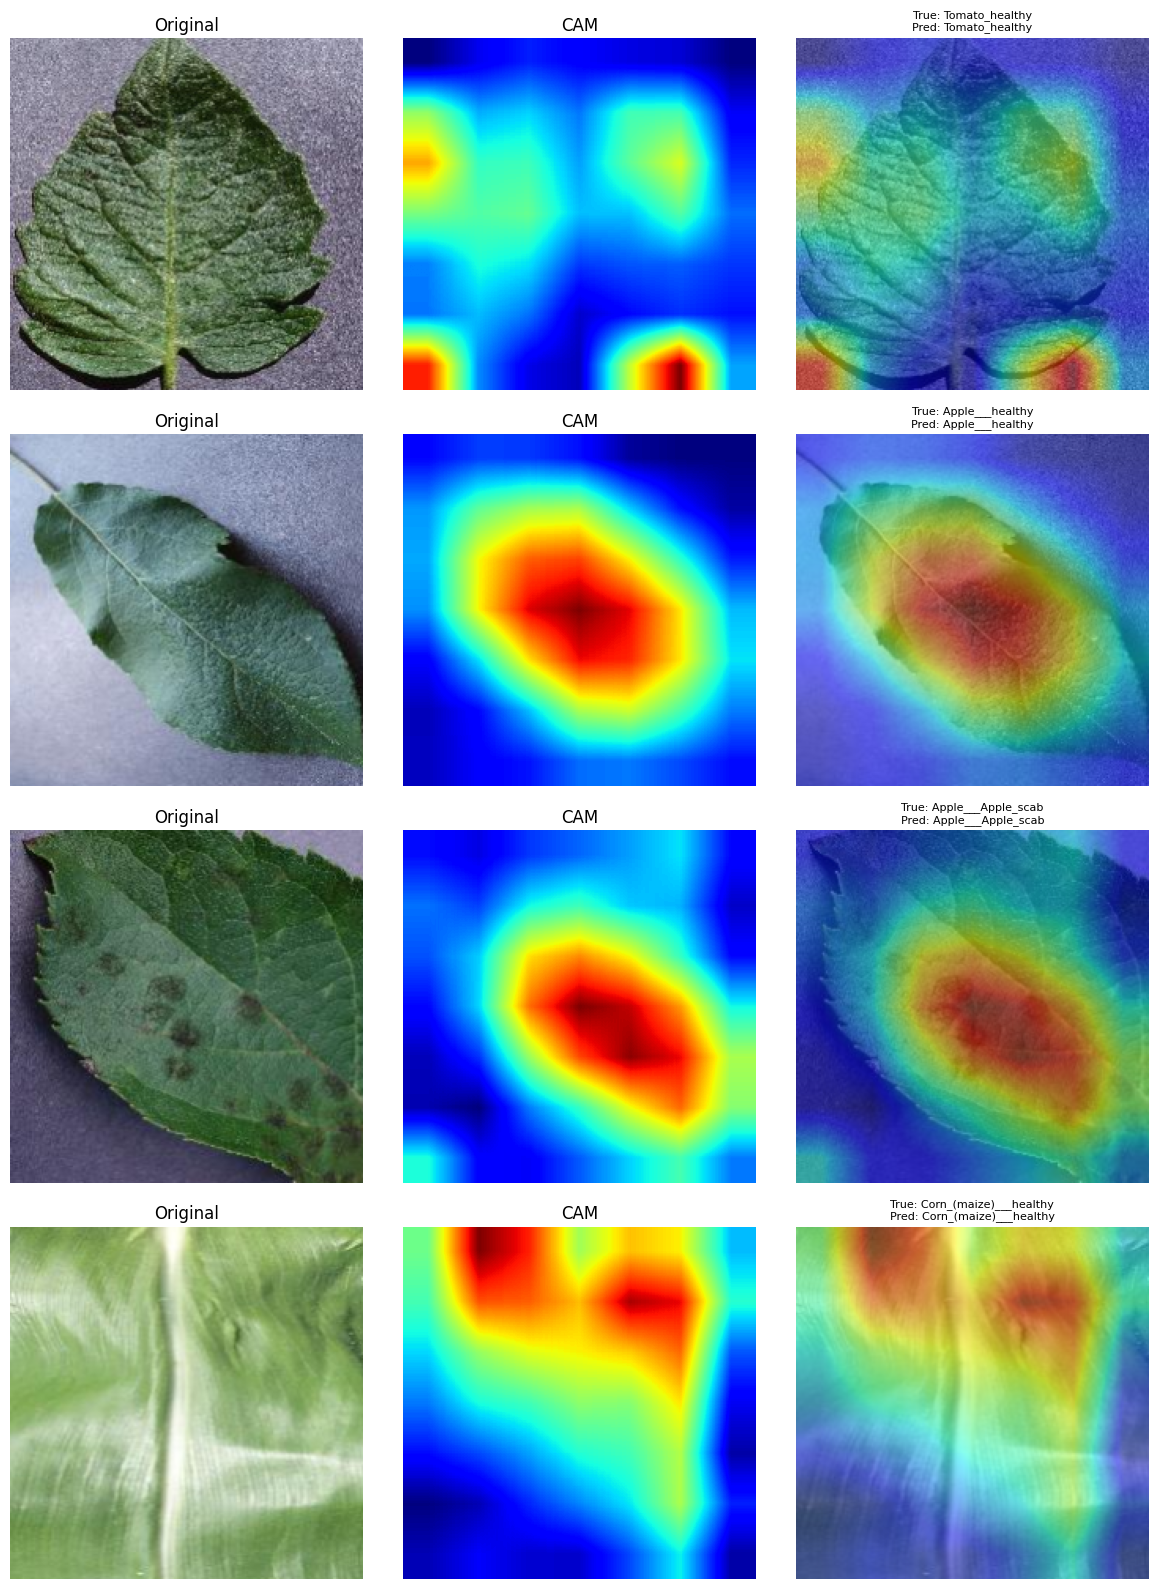

In [27]:
# ------------------------------------------------------------
# Grad-CAM
# ------------------------------------------------------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, _, __, output):
        self.activations = output.detach()

    def _save_gradients(self, _, __, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam).detach().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

def get_last_conv(model):
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    return last_conv

gradcam = GradCAM(best_model, get_last_conv(best_model))

indices = random.sample(range(len(test_ds)), min(4, len(test_ds)))
fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))

denorm = transforms.Compose([
    transforms.Normalize(mean=[0., 0., 0.], std=[1 / 0.229, 1 / 0.224, 1 / 0.225]),
    transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1., 1., 1.]),
])

if len(indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(indices):
    img_tensor, true_label = test_ds[idx]
    input_t = img_tensor.unsqueeze(0).to(DEVICE)
    cam = gradcam(input_t)
    pred_label = best_model(input_t).argmax(dim=1).item()

    img_display = denorm(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    ) / 255.0
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = 0.5 * img_display + 0.5 * heatmap

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cam_resized, cmap="jet")
    axes[row, 1].set_title("CAM")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(
        f"True: {CATEGORIES[true_label]}\nPred: {CATEGORIES[pred_label]}",
        fontsize=8,
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig(EXPORT_DIR / "gradcam_samples.png", dpi=160)
plt.show()


## 15. Single-Image Inference Check

**Purpose:** Runs a demo prediction on one held-out image and exports a simple prediction JSON.

In [28]:
# ------------------------------------------------------------
# Single-Image Inference Check
# ------------------------------------------------------------
def predict_single_image(model, image_path: str, labels: list[str], img_size: int = 224, top_k: int = 5):
    transform = transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).squeeze()

    top_probs, top_idxs = probs.topk(top_k)
    return [(labels[idx], float(prob)) for prob, idx in zip(top_probs.tolist(), top_idxs.tolist())]

demo_row = test_df.iloc[0]
demo_result = predict_single_image(best_model, demo_row["path"], CATEGORIES, IMG_SIZE, TOP_K)

demo_payload = {
    "image_path": demo_row["path"],
    "top_k_predictions": demo_result,
}
with open(EXPORT_DIR / "demo_prediction.json", "w", encoding="utf-8") as f:
    json.dump(demo_payload, f, indent=2)


## 16. Final Artifact Inventory

**Purpose:** Lists all generated artifacts so the Kaggle output folder can be checked before VS Code/Hugging Face deployment.

In [29]:
# ------------------------------------------------------------
# Final Artifact Inventory
# ------------------------------------------------------------
artifact_list = sorted([p.name for p in EXPORT_DIR.iterdir()])
with open(EXPORT_DIR / "artifact_inventory.json", "w", encoding="utf-8") as f:
    json.dump({"artifacts": artifact_list}, f, indent=2)

print("Artifacts available in:", EXPORT_DIR)
print(sorted([p.name for p in EXPORT_DIR.iterdir()]))


Artifacts available in: /kaggle/working/exports
['artifact_inventory.json', 'audit.csv', 'audit_summary.json', 'best_model.pt', 'class_balance_report.csv', 'class_distribution.png', 'classification_report.csv', 'config.json', 'confusion_matrix.png', 'demo_prediction.json', 'duplicate_candidates.csv', 'gradcam_samples.png', 'image_size_distribution.png', 'labels.json', 'metrics.json', 'per_class_accuracy.png', 'split_summary.csv', 'test_manifest.csv', 'train_manifest.csv', 'training_curves.png', 'training_history.csv', 'val_manifest.csv']
